In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import salem
import pandas as pd
import numpy as np
plt.style.use('ggplot')
from scipy.stats import spearmanr
import os
import glob

In [3]:
## Define data directories and file paths
datadir = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield'
os.makedirs(datadir, exist_ok=True)


In [69]:

crop_mask_file = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/crop_mask_fraction_on_sif_grid_conservative.nc'
crop_data_dir = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/inputs/hvstat'
crop_data_file = f"{crop_data_dir}/hvstat_africa_data_v1.2.csv"
admin_shapefile = f"{crop_data_dir}/hvstat_africa_boundary_v1.2.gpkg"
crop_data = pd.read_csv(crop_data_file)
admin_shp = gpd.read_file(admin_shapefile)
## Reading SIF data and shape file
syr, eyr = 2003, 2017
date_range = pd.date_range(start=f'{syr}-01-01', end=f'{eyr}-12-31', freq='ME')
sif_data = xr.open_mfdataset(f'/home/chc-shrad/DATA/SIF/fusion_SCIAMACHY_GOME-2/SIF_SCIAMACHY_GOME2_Harmonized.*_subsetted.nc4', 
                             concat_dim='time', combine='nested')
sif_data.coords['time'] = date_range
crop_mask = xr.open_dataset(crop_mask_file)

In [ ]:
for crop_type in ['Maize', 'Wheat', 'Rice', 'Sorghum', 'Millet']:
    # Subsetting crop data for a given crop type, quality control flag, and harvest year range
    sel_crop_data = crop_data[(crop_data['product'] == crop_type) & (crop_data['qc_flag']==0) & (crop_data['harvest_year']>=syr) & (crop_data['harvest_year']<=eyr)]
    # Getting unique subsets of crop data based on relevant columns
    unique_subsets = sel_crop_data[['country', 'fnid', 'product', 'crop_production_system', 'season_name', 'planting_year', 'planting_month', 'harvest_year', 'harvest_month', 'yield']].drop_duplicates()
    fnid = None
    # Loop over unique subsets in crop data to calculate seasonal SIF metrics and store results
    results = []
    for index, subset in unique_subsets.iterrows():
        #print (f"Processing subset: {subset.to_dict()}")

        fnid_new = subset['fnid']
        if fnid_new != fnid:
            fnid = fnid_new
            # Only subset the SIF and crop mask data if the fnid has changed
            print(f"Processing new fnid: {fnid}")
            fnid_admin_shp = admin_shp[admin_shp['fnid'] == fnid]
            if not fnid_admin_shp.empty:
                sif_subset = sif_data.salem.subset(shape=fnid_admin_shp, margin=2)
                crop_mask_subset = crop_mask.salem.subset(shape=fnid_admin_shp, margin=2)
                flag = True
            else:
                flag = False
        else:
            pass

        if flag:
            p_year = int(subset['planting_year'])
            p_month = int(subset['planting_month'])
            h_year = int(subset['harvest_year'])
            h_month = int(subset['harvest_month'])
                
            # Season window: from first day of planting month to end of harvest month
            season_start = pd.Timestamp(p_year, p_month, 1)
            season_end = pd.Timestamp(h_year, h_month, 1) + pd.offsets.MonthEnd(1)
            sif_season = sif_subset.sel(time=slice(season_start, season_end))['SIF_740_daily_corr']

            # Calculating different representation of seasonal SIF
            # Average of SIF over the growing season
            sif_season_mean = sif_season.mean(dim='time', skipna=True)
            sif_season_mean_masked = sif_season_mean*crop_mask_subset['crop_fraction']
            sif_season_max_masked = sif_season_mean_masked.where(sif_season_mean_masked>0, other=np.nan)

            # Maximum of SIF over the growing season
            sif_season_max = sif_season.max(dim='time', skipna=True)
            sif_season_max_masked = sif_season_max*crop_mask_subset['crop_fraction']
            sif_season_max_masked = sif_season_max_masked.where(sif_season_max_masked>0, other=np.nan)

            # Append to results
            results.append({
                'country': subset['country'],
                'fnid': subset['fnid'],
                'product':subset['product'],
                'crop_production_system':subset['crop_production_system'],
                'season_name':subset['season_name'],
                'planting_month': subset['planting_month'],
                'planting_year': subset['planting_year'],
                'harvest_month': subset['harvest_month'],
                'harvest_year': subset['harvest_year'],
                'yield': subset['yield'],
                'sif_mean': sif_season_mean.mean().values,
                'sif_max': sif_season_max.mean().values,
            })
            
        else:
            print(f"No shape file found for fnid: {fnid}. Skipping this subset.")
            continue

    results_df = pd.DataFrame(results)

    # Save results to CSV
    output_file = f"{datadir}/sif_and_yield_{syr}_{eyr}_{crop_type}.csv"
    print (f"Saving results to {output_file}")
    results_df.to_csv(output_file, index=False)

Processing new fnid: ZA1994A101
Processing new fnid: ZA1994A102
Processing new fnid: ZA1994A103
Processing new fnid: ZA1994A104
Processing new fnid: ZA1994A105
Processing new fnid: ZA1994A106
Processing new fnid: ZA1994A107
Processing new fnid: ZA1994A108
Processing new fnid: ZA1994A109


In [6]:
plotdir = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/results/figures/sif_vs_yield'
os.makedirs(plotdir, exist_ok=True)
datadir = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield'

Reading data from /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017_Maize_no_crop_mask.csv
Reading data from /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017_Maize_using_all_crop_mask.csv
Reading data from /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017_Maize_using_BEST_crop_specific_mask.csv
Reading data from /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017_Sorghum_no_crop_mask.csv
Reading data from /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017_Sorghum_using_all_crop_mask.csv
Input file /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017

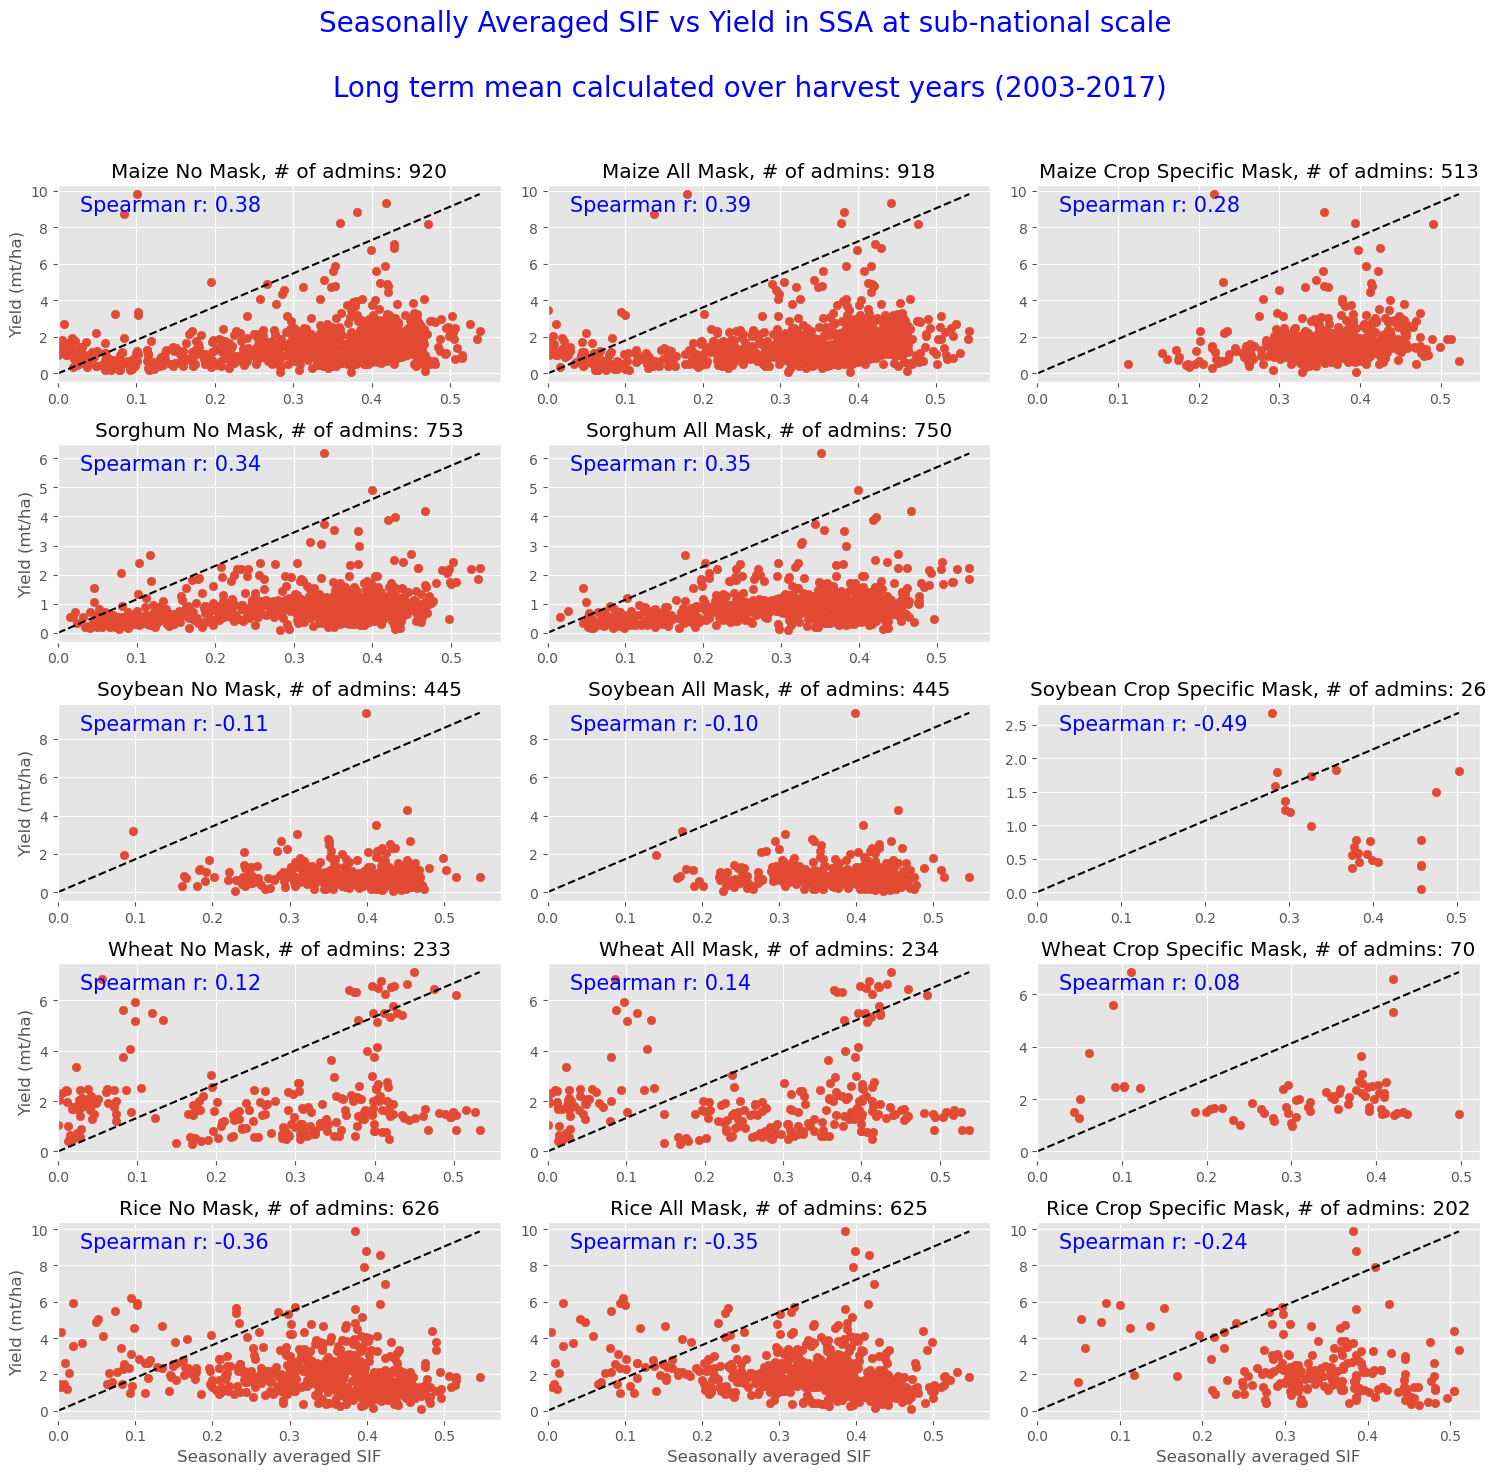

In [32]:
syr, eyr = 2003, 2017
fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes = axes.flatten()
cnt_plot=0
crop_type_list = ['Maize', 'Sorghum', 'Soybean', 'Wheat', 'Rice']
for crop_type in crop_type_list:
        for i, crop_mask_type in enumerate(['No Mask', 'All Mask', 'Crop Specific Mask']):
                ax=axes[cnt_plot]
                cnt_plot+=1
                if crop_mask_type == 'No Mask':
                        input_file = f"{datadir}/sif_and_yield_{syr}_{eyr}_{crop_type}_no_crop_mask.csv"
                elif crop_mask_type == 'All Mask':
                        input_file = f"{datadir}/sif_and_yield_{syr}_{eyr}_{crop_type}_using_all_crop_mask.csv"
                elif crop_mask_type == 'Crop Specific Mask':
                        input_file = f"{datadir}/sif_and_yield_{syr}_{eyr}_{crop_type}_using_BEST_crop_specific_mask.csv"

                if os.path.exists(input_file):
                        print (f"Reading data from {input_file}")
                        sif_yield_df = pd.read_csv(input_file)
                        sif_yield_df = sif_yield_df.dropna(subset=['sif_mean', 'yield'])
                        sif_yield_df_mean = sif_yield_df.groupby(['fnid'])[['sif_mean', 'yield']].mean()
                        sif_yield_df_mean = sif_yield_df_mean[(sif_yield_df_mean['sif_mean']>0) & (sif_yield_df_mean['yield']>0) & (sif_yield_df_mean['yield']<=10)]

                        ax.scatter(sif_yield_df_mean['sif_mean'], sif_yield_df_mean['yield'])
                        correlation, p_value = spearmanr(sif_yield_df_mean['sif_mean'], sif_yield_df_mean['yield'])
                        ax.annotate(f"Spearman r: {correlation:.2f}", xy=(0.05, 0.95), xycoords='axes fraction', fontsize=15, verticalalignment='top', color='blue')
                        sample = sif_yield_df_mean.shape[0]
                        ax.set_title(f"{crop_type} {crop_mask_type}, # of admins: {sample}")
                
                        #ax.set_ylim(0, 10)
                        ax.set_xlim(0, sif_yield_df_mean['sif_mean'].max()*1.05)
                        ax.plot([0, sif_yield_df_mean['sif_mean'].max()], [0, sif_yield_df_mean['yield'].max()], 'k--')  # Add a reference line
                        if (crop_type==crop_type_list[-1]):  # Only set xlabel for the last crop type to avoid overlapping labels
                                ax.set_xlabel('Seasonally averaged SIF')
                        else: pass
                        if (crop_mask_type=='No Mask'):
                                ax.set_ylabel('Yield (mt/ha)')
                        else: pass
                else:
                        print (f"Input file {input_file} does not exist. Skipping this combination of crop type and mask type.")
                        fig.delaxes(ax)  # Remove the axis if the input file does not exist
fig.suptitle(f"Seasonally Averaged SIF vs Yield in SSA at sub-national scale\n\n Long term mean calculated over harvest years ({syr}-{eyr})", fontsize=20, color='blue')
plt.tight_layout(rect=[0, 0, 1, 0.96])
#
output_plot_file = f"{plotdir}/mean_sif_vs_mean_yield_{syr}_{eyr}_across_different_crop_mask.png"
print (f"Saving plot to {output_plot_file}")
plt.savefig(output_plot_file, dpi=300)

In [4]:
crop_data_dir = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/inputs/hvstat'
admin_shapefile = f"{crop_data_dir}/hvstat_africa_boundary_v1.2.gpkg"
admin_shp = gpd.read_file(admin_shapefile)


Reading data from /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017_Maize_no_crop_mask.csv
Reading data from /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017_Maize_using_all_crop_mask.csv
Reading data from /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017_Maize_using_BEST_crop_specific_mask.csv
Reading data from /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017_Sorghum_no_crop_mask.csv
Reading data from /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017_Sorghum_using_all_crop_mask.csv
Input file /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/sif_vs_yield/sif_and_yield_2003_2017

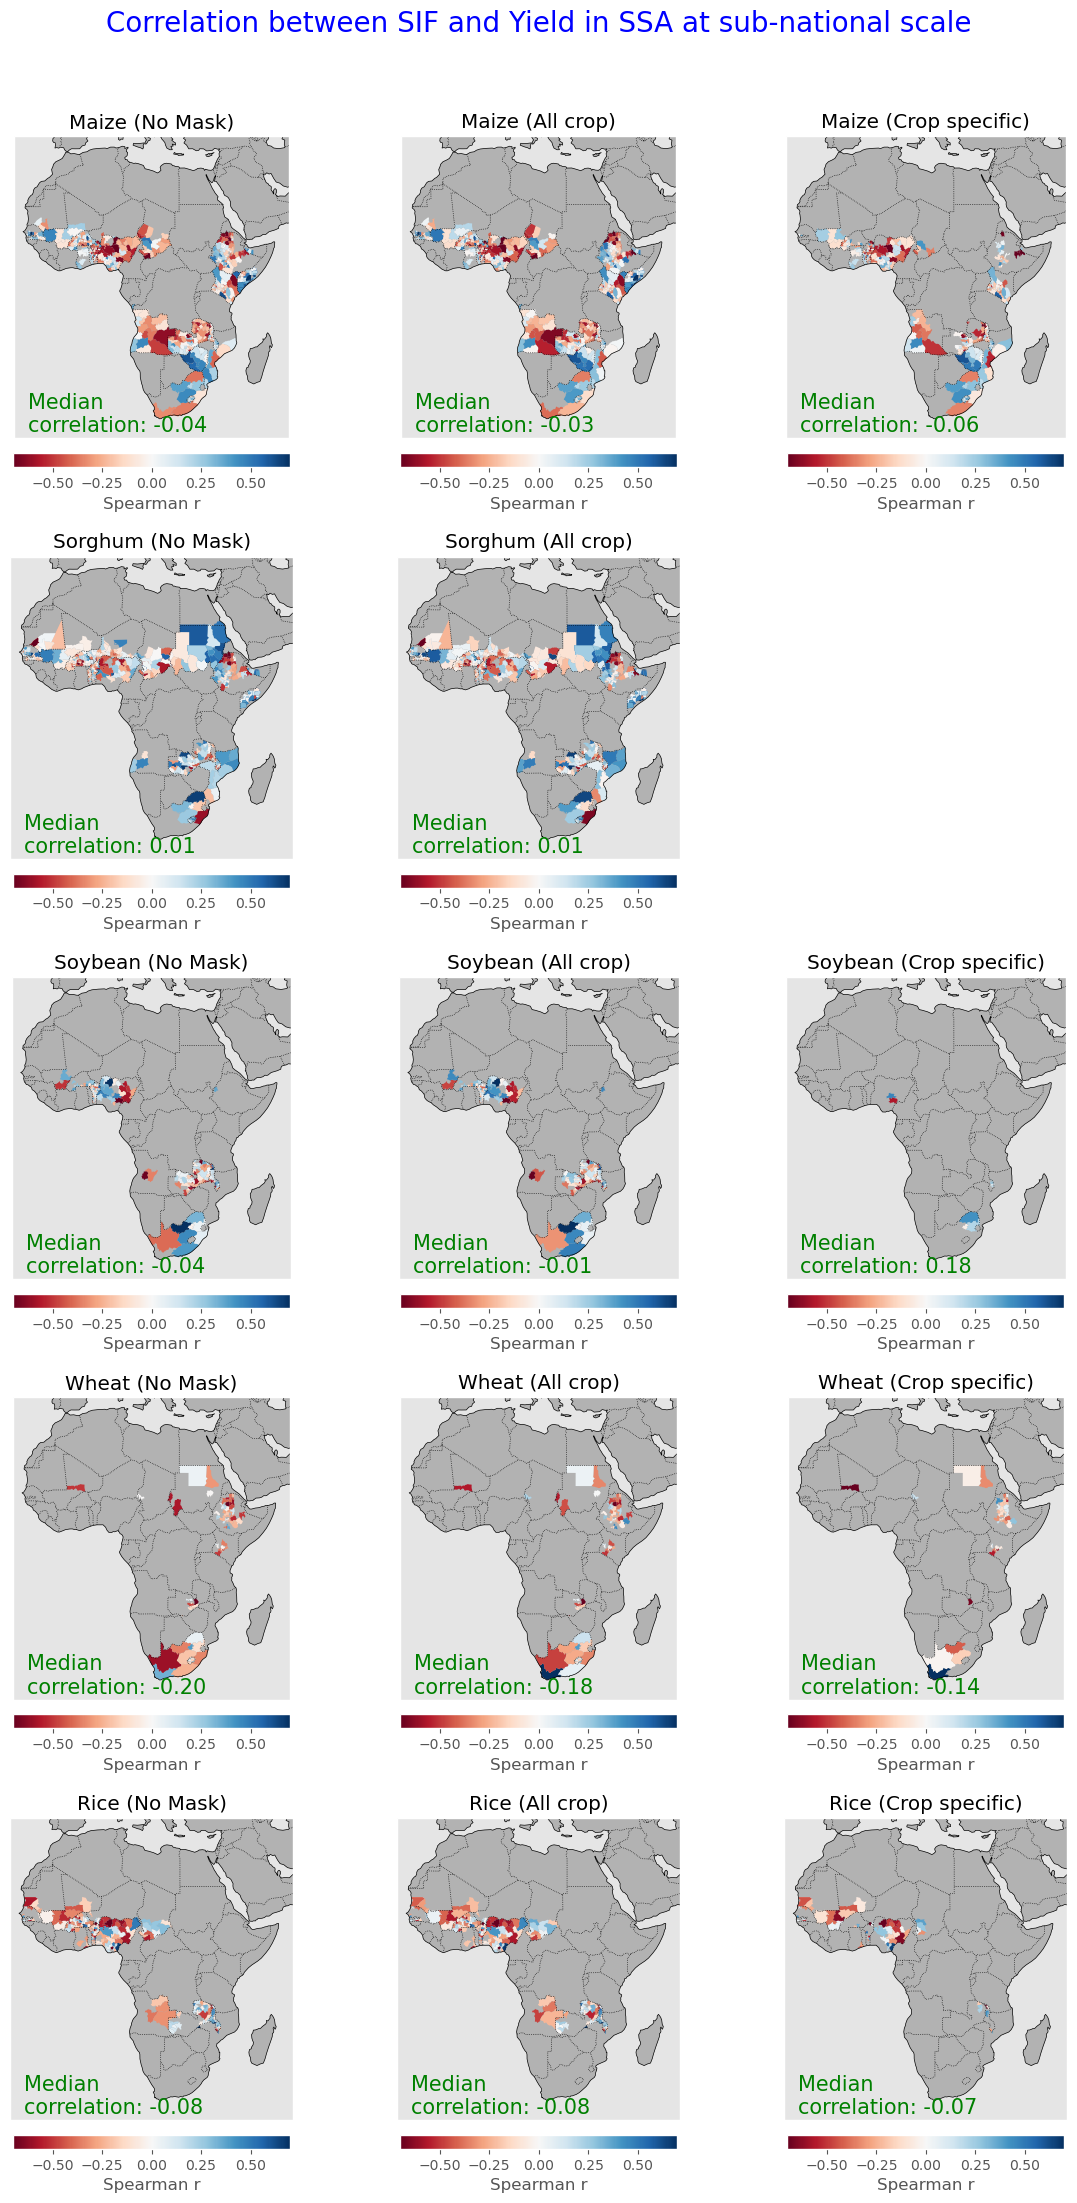

In [8]:

corr_results = []

syr, eyr = 2003, 2017
fig, axes = plt.subplots(5, 3, figsize=(8*1.5, 15*1.5), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()
cnt_plot=0
crop_type_list = ['Maize', 'Sorghum', 'Soybean', 'Wheat', 'Rice']
#crop_type_list = ['Maize', 'Sorghum']
for crop_type in crop_type_list:
    for i, crop_mask_type in enumerate(['No Mask', 'All crop', 'Crop specific']):
        
        ax=axes[cnt_plot]
        ax.set_extent([-20, 55, -40, 40], crs=ccrs.PlateCarree())
        cnt_plot+=1
        if crop_mask_type == 'No Mask':
                input_file = f"{datadir}/sif_and_yield_{syr}_{eyr}_{crop_type}_no_crop_mask.csv"
        elif crop_mask_type == 'All crop':
                input_file = f"{datadir}/sif_and_yield_{syr}_{eyr}_{crop_type}_using_all_crop_mask.csv"
        elif crop_mask_type == 'Crop specific':
                input_file = f"{datadir}/sif_and_yield_{syr}_{eyr}_{crop_type}_using_BEST_crop_specific_mask.csv"

        if os.path.exists(input_file):
                corr_results = []  # Reset correlation results for each crop type
                print (f"Reading data from {input_file}")
                sif_yield_df = pd.read_csv(input_file)
                sif_yield_df = sif_yield_df.dropna(subset=['sif_mean', 'yield'])

                groups = sif_yield_df.groupby(['fnid', 'crop_production_system', 'season_name']).groups
                for name, group in groups.items():
                    #print(f"Group: {name}, Number of records: {len(group)}")
                    if len(group) > 10:
                        sif_yield_group = sif_yield_df.loc[group]
                        correlation, p_value = spearmanr(sif_yield_group['sif_mean'], sif_yield_group['yield'])
                        corr_results.append({
                            'fnid': name[0],
                            'crop_production_system': name[1],
                            'season_name': name[2],
                            'spearman_r': correlation,
                            'p_value': p_value,
                            'num_records': len(group)
                        })
                corr_df = pd.DataFrame(corr_results)
                merged_df = pd.merge(corr_df, admin_shp, on='fnid', how='left')
                merged_gdf = gpd.GeoDataFrame(merged_df, geometry='geometry')
                cs = merged_gdf.plot(column='spearman_r', cmap='RdBu', vmin=-0.7, vmax=0.7, legend=True, legend_kwds={'orientation': 'horizontal', 'label': 'Spearman r', 'shrink': 0.7, 'pad': 0.04}, ax=ax, edgecolor=None)
                ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
                ax.add_feature(cfeature.COASTLINE, edgecolor='black')
                ax.add_feature(cfeature.LAND, facecolor='gray', alpha=0.5)
                median_spearman_r = merged_gdf['spearman_r'].median()
                ax.annotate(f"Median\ncorrelation: {median_spearman_r:.2f}", xy=(0.05, 0.15), xycoords='axes fraction', fontsize=15, verticalalignment='top', color='green')
                ax.set_title(f"{crop_type} ({crop_mask_type})")
                del merged_df
                del merged_gdf
                
        else:
                print (f"Input file {input_file} does not exist. Skipping this combination of crop type and mask type.")
                fig.delaxes(ax)  # Remove the axis if the input file does not exist


fig.suptitle(f"Correlation between SIF and Yield in SSA at sub-national scale", fontsize=20, color='blue')
plt.tight_layout(rect=[0, 0, 1, 0.96])

output_plot_file = f"{plotdir}/sif_vs_yield_interannual_correlation_{syr}_{eyr}_across_different_crop_mask.png"
print (f"Saving plot to {output_plot_file}")
plt.savefig(output_plot_file, dpi=300)

In [3]:
data = pd.read_hdf('/home/cape/data2/data_processed/output/data_product_day_ifpri.hdf')

In [5]:
noaa_fcst = xr.open_dataset('/home/chc-shrad/DATA/Crop_yield_forecasting/noaa_experimental_climate_forecasts/CHIRPS3_Prate_Monthly_Forecasts_1981_2023_leads1-12_1x1deg.nc')

In [10]:
noaa_fcst

<xarray.Dataset> Size: 2GB
Dimensions:          (time: 516, latitude: 121, longitude: 360, leads: 12)
Coordinates:
  * time             (time) datetime64[ns] 4kB 1981-01-01 ... 2023-12-01
  * latitude         (latitude) float64 968B -60.0 -59.0 -58.0 ... 59.0 60.0
  * longitude        (longitude) float64 3kB -180.0 -179.0 ... 178.0 179.0
  * leads            (leads) float64 96B 1.0 2.0 3.0 4.0 ... 9.0 10.0 11.0 12.0
Data variables:
    precip_forecast  (time, leads, latitude, longitude) float64 2GB ...

In [11]:
noaa_fcst['latitude']

<xarray.DataArray 'latitude' (latitude: 121)> Size: 968B
array([-60., -59., -58., -57., -56., -55., -54., -53., -52., -51., -50., -49.,
       -48., -47., -46., -45., -44., -43., -42., -41., -40., -39., -38., -37.,
       -36., -35., -34., -33., -32., -31., -30., -29., -28., -27., -26., -25.,
       -24., -23., -22., -21., -20., -19., -18., -17., -16., -15., -14., -13.,
       -12., -11., -10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,
         0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,  23.,
        24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,  34.,  35.,
        36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,  46.,  47.,
        48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.,
        60.])
Coordinates:
  * latitude  (latitude) float64 968B -60.0 -59.0 -58.0 -57.0 ... 58.0 59.0 60.0
Attributes:
    standard_name:        latitude
    long_name:            latitude
    units:                degrees north
    _CoordinateAxisType:  Lat